# Ablation 3: SGD -> Adam Optimizer GAN Experiment



In [1]:
# allowing project modules
import sys
import os

# Adds the parent directory to the python path
sys.path.append(os.path.abspath('../..'))

import torch
from torch.optim import SGD

# in project imports
from gan.models.preprocessing import train_loader, val_loader, test_loader
from gan.models.config import NUM_PIECES, LEARN_RATE, NUM_EPOCHS, LATENT_D
from gan.models.discriminator import Discriminator
from gan.models.generator import Generator
from gan.models.train import fit
from gan.models.evaluate import evaluate


## Ensuring Reproducibility

In [2]:
# global random seed for all experiments to ensure reproducibility
seed = 42
torch.manual_seed(seed)
g = torch.Generator()
g.manual_seed(seed)

## Preprocessing Data

In [3]:
import torch
import torchvision
from torchvision.transforms import v2
from torchvision.datasets import MNIST
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split

# in-project imports
from gan.models.config import DATA_FLODER_PATH, VAL_SET_LENGTH, NUM_WORKERS, BATCH_SIZE

# load dataset
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_dataset = MNIST(root=DATA_FLODER_PATH, train=True, download=True, transform=transform)
test_dataset = MNIST(root=DATA_FLODER_PATH, train=False, download=True, transform=transform)

# create dataloaders
train_length = len(train_dataset) - VAL_SET_LENGTH
train_ds, val_ds = random_split(train_dataset, [train_length, VAL_SET_LENGTH], generator=g)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

### Calculating the fixed bias for the output layer for generator

In [4]:
train_images, *_ = train_dataset.data.float()

images = train_dataset.data.float().reshape(-1, 784)

pixel_probs = images.mean(dim=0)

eps = 1e-7
pixel_probs = pixel_probs.clamp(eps, 1 - eps)

output_bias = torch.log(
    pixel_probs / (1 - pixel_probs)
)

print(output_bias.shape)

output_bias

torch.Size([784])


tensor([-16.1181, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181,
        -16.1181, -16.1181, -16.1181, -16.1181, -16.1181,  -6.1637,  -4.8415,
         -5.6232,  -8.8047, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181,
        -16.1181, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181,
        -16.1181, -16.1181, -16.1181, -16.1181,  -8.2292,  -6.9938,  -4.6702,
         -3.6934,  -3.0853,  -2.6811,  -1.9912,  -1.6528,  -1.5563,  -1.5338,
         -1.4545,  -1.5565,  -1.4701,  -1.7063,  -2.1959,  -2.5679,  -2.8669,
         -3.8243,  -4.5867,  -5.6420, -16.1181, -16.1181, -16.1181, -16.1181,
        -16.1181, -16.1181,  -6.8421,  -7.2637,  -4.9620,  -5.2005,  -3.0072,
         -1.8286,  -1.0243,   0.0265,   1.8730,  15.9424,  15.9424,  15.9424,
         15.9424,  15.9424,  15.9424,  15.9424,  15.9424,  15.9424,  15.9424,
          0.5470,  -0.8656,  -2.2659,  -3.3104,  -4.7435, -16.1181, -16.1181,
        -16.1181, -16.1181,  -5.7310,  -5.1354,  -4.4094,  -2.59

## Training Setup

In [5]:
# setup trainning
D_model = Discriminator(num_pieces=NUM_PIECES)
G_model = Generator(output_bias)

# ablation 3 changes the optimizer
D_optimizer = torch.optim.Adam(
    D_model.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

G_optimizer = torch.optim.Adam(
    G_model.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G_model = G_model.to(device)
D_model = D_model.to(device)

# time of training
def recorded_time(elapsed_time):
    minutes = int(elapsed_time // 60)
    seconds = round((elapsed_time / 60 - minutes) * 60)
    print(f"time: {minutes}m {seconds}s")

## Training

Epoch 1/22:
	Discriminator Train   Loss: 0.0184
	Generator Train       Loss: 10.2192
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.9465


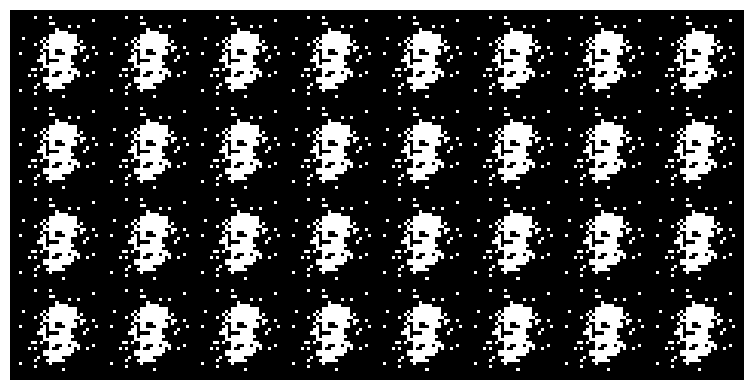

Epoch 2/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 15.2199
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 16.1658
Epoch 3/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 16.8983
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 17.4622
Epoch 4/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 18.0069
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 18.4579
Epoch 5/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 18.6437
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 18.4190


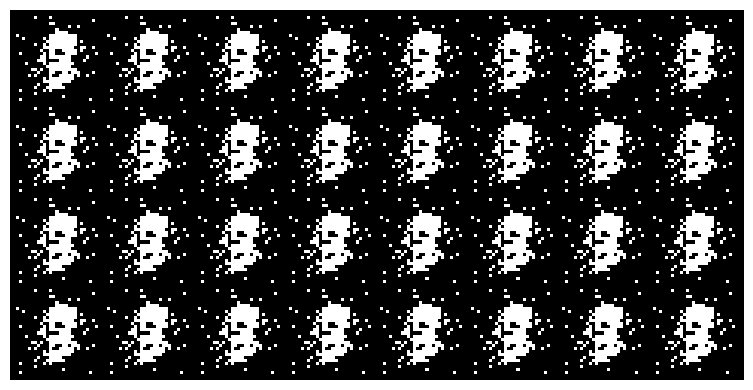

Epoch 6/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 19.1991
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 19.6181
Epoch 7/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 19.5011
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 19.8944
Epoch 8/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 20.1889
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 20.6817
Epoch 9/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 20.1693
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 20.8871
Epoch 10/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 21.0881
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 21.3074


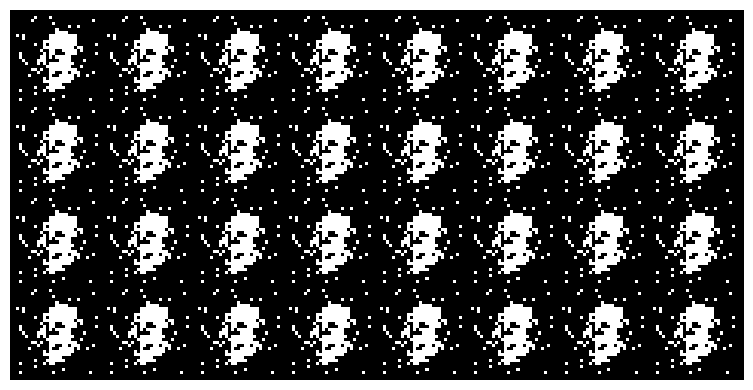

Epoch 11/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 21.7173
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 22.0649
Epoch 12/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 22.3401
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 22.5884
Epoch 13/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 22.8670
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 23.1298
Epoch 14/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 23.4085
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 23.6284
Epoch 15/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 23.9114
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 24.1844


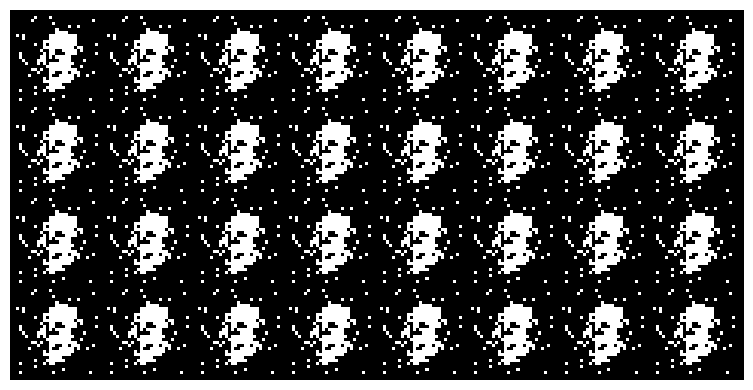

Epoch 16/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 24.4417
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 24.7030
Epoch 17/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 24.9374
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 25.1586
Epoch 18/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 25.3772
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 25.6023
Epoch 19/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 25.8024
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 25.9901
Epoch 20/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 26.1675
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 26.3236


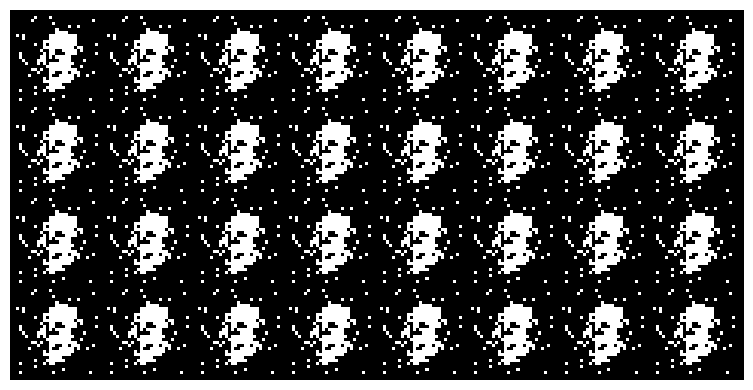

Epoch 21/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 26.3067
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 26.1308
Epoch 22/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 26.3774
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 26.5853


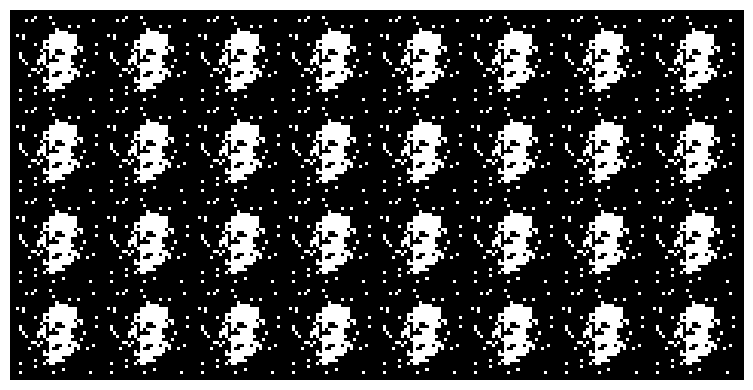

time: 157m 2s


In [6]:
from time import time
start_time = time() # start the timer

# training
history = fit(
    G_model=G_model,
    D_model=D_model,
    epochs=NUM_EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    latent_d=LATENT_D,
    optimizer_D=D_optimizer,
    optimizer_G=G_optimizer,
    loss_generator=G_model.saturated_loss,
    loss_discriminator=D_model.loss,
    device=device,
    optimizer_choice="Adam"
)


elapsed = time() - start_time    
recorded_time(elapsed)

In [7]:
print(history)

{'D': {'train': [0.018352918078706596, 4.1970908571746855e-06, 7.020022602292228e-07, 2.091441590652584e-07, 9.151281214693905e-08, 4.57358527903591e-08, 2.3734248088740034e-08, 1.2975399124097446e-08, 7.982101396004801e-09, 4.240115144044216e-09, 2.22850245969773e-09, 1.1202093757470386e-09, 5.982393975949601e-10, 3.289124570912922e-10, 1.9067387776737644e-10, 9.533693661067882e-11, 5.720216139815495e-11, 3.575135069626798e-11, 1.906738703800959e-11, 7.150270139253597e-12, 7.150270139253597e-12, 4.766846759502398e-12], 'val': [1.0635464191727807e-05, 1.8543606931416434e-06, 4.111846644889283e-07, 1.8138371210767445e-07, 9.248474339926815e-08, 4.90791980467975e-08, 2.927809878485732e-08, 1.705896280128627e-08, 1.1217646530781167e-08, 6.175059417046214e-09, 3.4928387833588203e-09, 1.99079760108134e-09, 1.1920939073206681e-09, 7.271770925854071e-10, 4.6491642535784193e-10, 3.099442452025869e-10, 2.026558433954051e-10, 1.3113024124322692e-10, 1.0728837480655784e-10, 1.0728837480655784e-10

# Test 

In [8]:
# test
test_result = evaluate(
    D_model=D_model,
    G_model=G_model,
    data_loader=test_loader,
    loss_D_fn=D_model.loss,
    loss_G_fn=G_model.loss,
    latent_d=LATENT_D,
    device=device
)

In [9]:
D_test_loss, G_test_loss = test_result
print("Test Results")
print("\tDiscriminator: ", D_test_loss)
print("\tGenerator:     ", G_test_loss)

Test Results
	Discriminator:  1.5497212473292164e-10
	Generator:      0.0


## Results

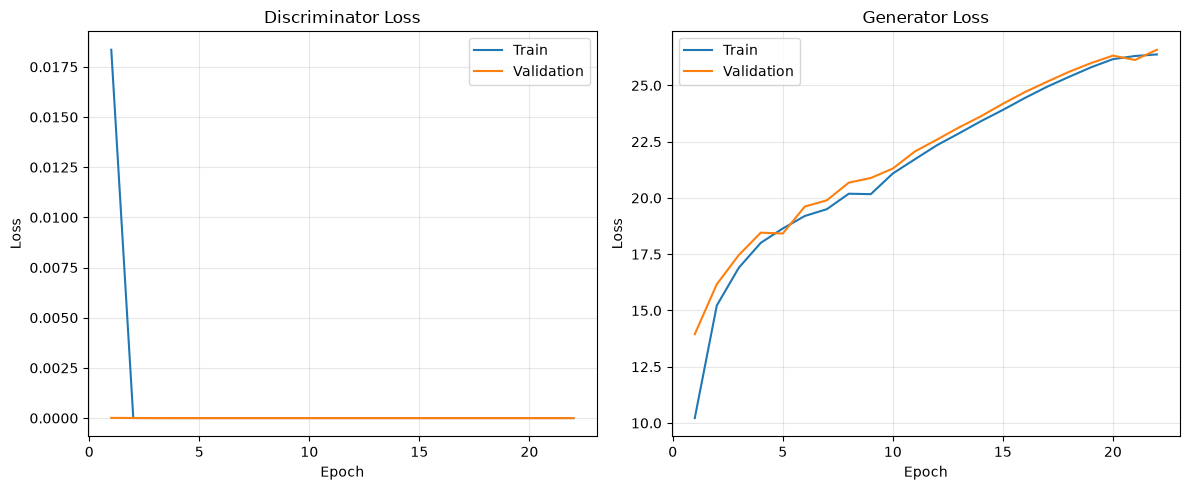

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["D"]["train"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Discriminator
axes[0].plot(epochs, history["D"]["train"], label="Train")
axes[0].plot(epochs, history["D"]["val"], label="Validation")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Discriminator Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generator
axes[1].plot(epochs, history["G"]["train"], label="Train")
axes[1].plot(epochs, history["G"]["val"], label="Validation")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Generator Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()